In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_validate
import joblib
import os

os.makedirs('../models', exist_ok=True)
print("Imports done ✅")

Imports done ✅


In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())

X_train shape: (219136, 142)
X_test shape: (30223, 142)
y_train distribution:
 class
0    109568
1    109568
Name: count, dtype: int64


In [3]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc_pr = average_precision_score(y_test, y_prob)
    auc_roc = roc_auc_score(y_test, y_prob)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  AUC-PR  : {auc_pr:.4f}")
    print(f"  AUC-ROC : {auc_roc:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Legit','Fraud'])}")

    # Confusion matrix
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Legit', 'Fraud'],
        cmap='Blues', ax=axes[0]
    )
    axes[0].set_title(f'{name} — Confusion Matrix')

    PrecisionRecallDisplay.from_estimator(
        model, X_test, y_test, ax=axes[1], name=name
    )
    axes[1].set_title(f'{name} — Precision-Recall Curve')

    plt.tight_layout()
    plt.savefig(f'../data/processed/{name.replace(" ", "_")}_eval.png', dpi=150)
    plt.show()

    return {'model': name, 'AUC-PR': auc_pr, 'AUC-ROC': auc_roc}

Training Logistic Regression...

  Logistic Regression
  AUC-PR  : 0.3180
  AUC-ROC : 0.7376

              precision    recall  f1-score   support

       Legit       0.95      0.73      0.83     27393
       Fraud       0.20      0.65      0.30      2830

    accuracy                           0.72     30223
   macro avg       0.57      0.69      0.56     30223
weighted avg       0.88      0.72      0.78     30223



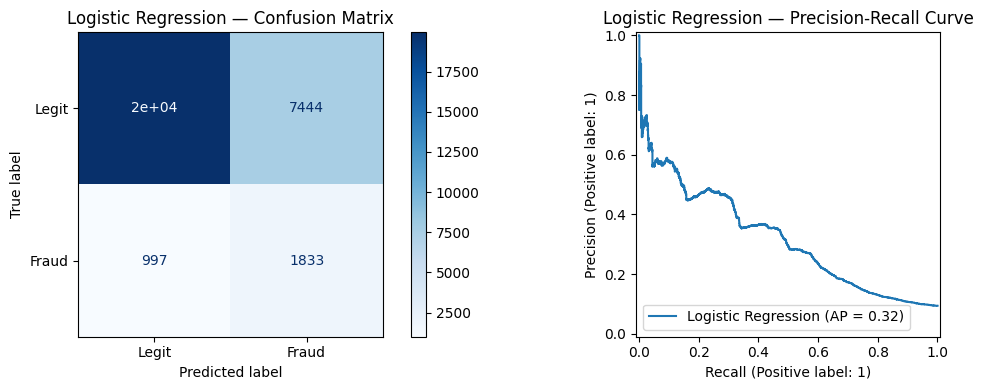

Model saved ✅


In [4]:
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train, y_train)

lr_results = evaluate_model("Logistic Regression", lr, X_test, y_test)
joblib.dump(lr, '../models/logistic_regression_fraud.pkl')
print("Model saved ✅")

Training XGBoost...

  XGBoost
  AUC-PR  : 0.6174
  AUC-ROC : 0.7694

              precision    recall  f1-score   support

       Legit       0.95      1.00      0.98     27393
       Fraud       0.95      0.54      0.69      2830

    accuracy                           0.95     30223
   macro avg       0.95      0.77      0.83     30223
weighted avg       0.95      0.95      0.95     30223



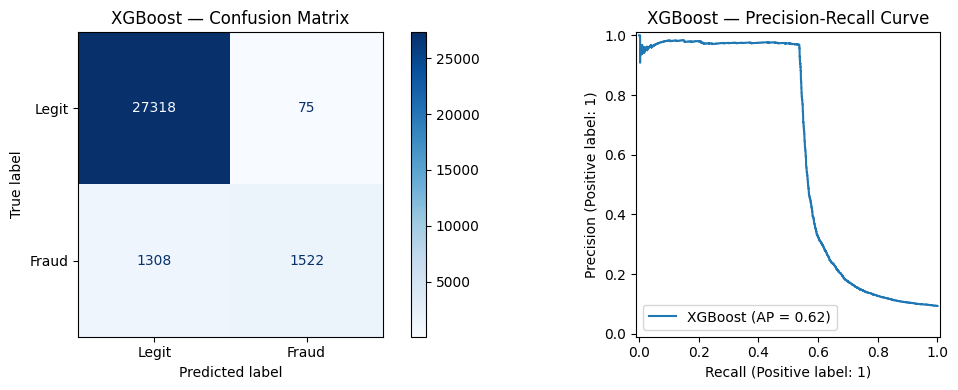

Model saved ✅


In [5]:
print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

xgb_results = evaluate_model("XGBoost", xgb, X_test, y_test)
joblib.dump(xgb, '../models/xgboost_fraud.pkl')
print("Model saved ✅")

In [6]:
print("Running Stratified K-Fold CV on XGBoost...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                  eval_metric='aucpr', random_state=42, n_jobs=-1),
    X_train, y_train,
    cv=cv,
    scoring=['average_precision', 'roc_auc'],
    n_jobs=-1
)

print(f"AUC-PR  — Mean: {cv_results['test_average_precision'].mean():.4f} "
      f"± {cv_results['test_average_precision'].std():.4f}")
print(f"AUC-ROC — Mean: {cv_results['test_roc_auc'].mean():.4f} "
      f"± {cv_results['test_roc_auc'].std():.4f}")

Running Stratified K-Fold CV on XGBoost...
AUC-PR  — Mean: 0.9652 ± 0.0008
AUC-ROC — Mean: 0.9532 ± 0.0013



=== Model Comparison (Fraud_Data) ===
                     AUC-PR  AUC-ROC
model                               
XGBoost              0.6174   0.7694
Logistic Regression  0.3180   0.7376


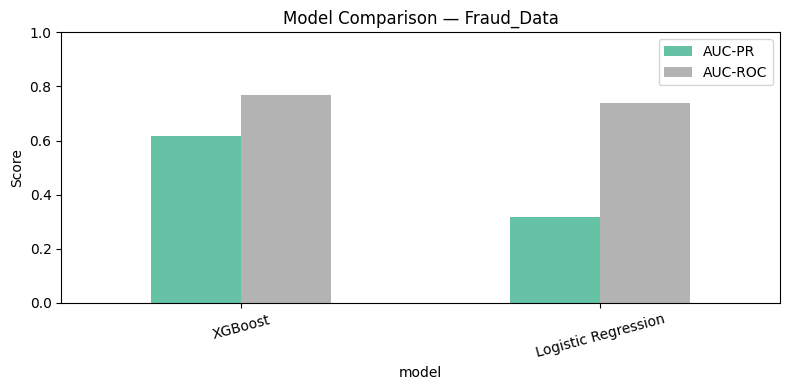

In [7]:
results_df = pd.DataFrame([lr_results, xgb_results])
results_df = results_df.set_index('model')
results_df = results_df.sort_values('AUC-PR', ascending=False)

print("\n=== Model Comparison (Fraud_Data) ===")
print(results_df.round(4))

results_df.plot(kind='bar', figsize=(8, 4), colormap='Set2', ylim=(0, 1))
plt.title('Model Comparison — Fraud_Data')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../data/processed/model_comparison_fraud.png', dpi=150)
plt.show()